In [1]:
# STEP 00: IMPORTING THE LIBRARIES

# We are going to do a customer segmentation type of project
# Most companies will collect data on customers
# There are a lot of stuff that we can deal with it

# If you have a lot of customers in your business
# you have need to create some grouping of these customers

import numpy as np
import pandas as pd
import datetime
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import AgglomerativeClustering
from matplotlib.colors import ListedColormap
from sklearn import metrics
import warnings
import sys
if not sys.warnoptions:
  warnings.simplefilter("ignore")
np.random.seed(42)

In [2]:
# STEP 01: LOADING THE DATASETS

data = pd.read_csv('01_marketing_campaign_datasets_DA_ML.csv', sep="\t")
print("Number of datapoints:", len(data))
data.head()

Number of datapoints: 2240


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [3]:
# STEP 02: INFORMATION ON FEATURES
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [4]:
# STEP 03: REMOVES THE 'NA' VALUES
data = data.dropna()
print("The total number of data-points after removing the rows with missing values are: ", len(data))

The total number of data-points after removing the rows with missing values are:  2216


In [5]:
# STEP 04: CONVERTING
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
dates = [] # Created a list for the dates
for i in data["Dt_Customer"]:
    i = i.date()
    dates.append(i)

# Dates of the newest and oldest recorded customer
print("The newest customer's enrolment date in the record: ", max(dates))
print("The oldest customer's enrolment date in the record: ", min(dates))

The newest customer's enrolment date in the record:  2014-06-29
The oldest customer's enrolment date in the record:  2012-07-30


In [6]:
# STEP 05: CREATED A FEATURE "Customer_For"

days = [] # Calculated and stored it in the list
d1 = max(dates) # Taking it to be the newest customer
for i in dates:
    delta = d1 - i
    days.append(delta)
data["Customer_For"] = days
data["Customer_For"] = pd.to_numeric(data["Customer_For"], errors="coerce")

# We need a numerictical data to processing!

In [7]:
# STEP 06: CHECKED THE TOTAL FEATURES IN THE CATEGORIES

print("Total categories in the feature Marital_Status:\n", data["Marital_Status"].value_counts(), "\n")
print("Total categories in the feature Education:\n", data["Education"].value_counts())

# Just to have an idea of the values that we have in specific columns
# count of the appearances!

Total categories in the feature Marital_Status:
 Marital_Status
Married     857
Together    573
Single      471
Divorced    232
Widow        76
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64 

Total categories in the feature Education:
 Education
Graduation    1116
PhD            481
Master         365
2n Cycle       200
Basic           54
Name: count, dtype: int64


In [8]:
#STEP 07: FEATURE ENGINEERING (IMPORTANT!)


# 1. Age of customer today
# Make it more simpler
data["Age"] = 2025-data["Year_Birth"]

# 2. Total spendings on various items
# Just sum all the amount values that we have in our data
data["Spent"] = data["MntWines"]+ data["MntFruits"]+ data["MntMeatProducts"]+ data["MntFishProducts"]+ data["MntSweetProducts"]+ data["MntGoldProds"]

# 3. Deriving living situation by marital status: "Alone"
# Categories make it simpler for those who have a partners or not
data["Living_With"]=data["Marital_Status"].replace({"Married":"Partner", "Together":"Partner", "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone",})

# 4. Feature indicating total children living in the household
# Calculated the number of the children in the household
data["Children"]=data["Kidhome"]+data["Teenhome"]

# 5. Feature for total members in the household
# Make a new column: "Family_Size" to categorize "Alone" or "Partners"
data["Family_Size"] = data["Living_With"].replace({"Alone": 1, "Partner":2})+ data["Children"]

# 6. Feature pertaining parenthood
# When the children is higher than 0, parents will be 1, otherwise 0
data["Is_Parent"] = np.where(data.Children> 0, 1, 0)

# 7. Segmenting education levels in three groups
# Simpler categorize
data["Education"]=data["Education"].replace({"Basic":"Undergraduate","2n Cycle":"Undergraduate", "Graduation":"Graduate", "Master":"Postgraduate", "PhD":"Postgraduate"})

# 8. For clarity
# Make them easier name to remember and work for it
data=data.rename(columns={"MntWines": "Wines","MntFruits":"Fruits","MntMeatProducts":"Meat","MntFishProducts":"Fish","MntSweetProducts":"Sweets","MntGoldProds":"Gold"})

# Dropping some of the redundant features
# Business Acument = columns that we think potenlly not gonna use as part of the project. kill it.
to_drop = ["Marital_Status", "Dt_Customer", "Z_CostContact", "Z_Revenue", "Year_Birth", "ID"]
data = data.drop(to_drop, axis=1)

In [9]:
data.describe()

# Important
# Check some statistics on our data

,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,Gold,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_For,Age,Spent,Children,Is_Parent
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000
mean,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,27.028881,43.965253,...,0.073105,0.064079,0.013538,0.009477,0.150271,3.054423e+13,56.179603,607.075361,0.947202,0.714350
std,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,41.072046,51.815414,...,0.260367,0.244950,0.115588,0.096907,0.357417,1.749036e+13,11.985554,602.900476,0.749062,0.451825
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,29.000000,5.000000,0.000000,0.000000
25%,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.555200e+13,48.000000,69.000000,0.000000,0.000000
50%,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,8.000000,24.500000,...,0.000000,0.000000,0.000000,0.000000,0.000000,3.071520e+13,55.000000,396.500000,1.000000,1.000000
75%,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,33.000000,56.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,4.570560e+13,66.000000,1048.000000,1.000000,1.000000
max,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,6.039360e+13,132.000000,2525.000000,3.000000,1.000000


Relative Plot Of Some Selected Features: A Data Subset


<Figure size 800x550 with 0 Axes>

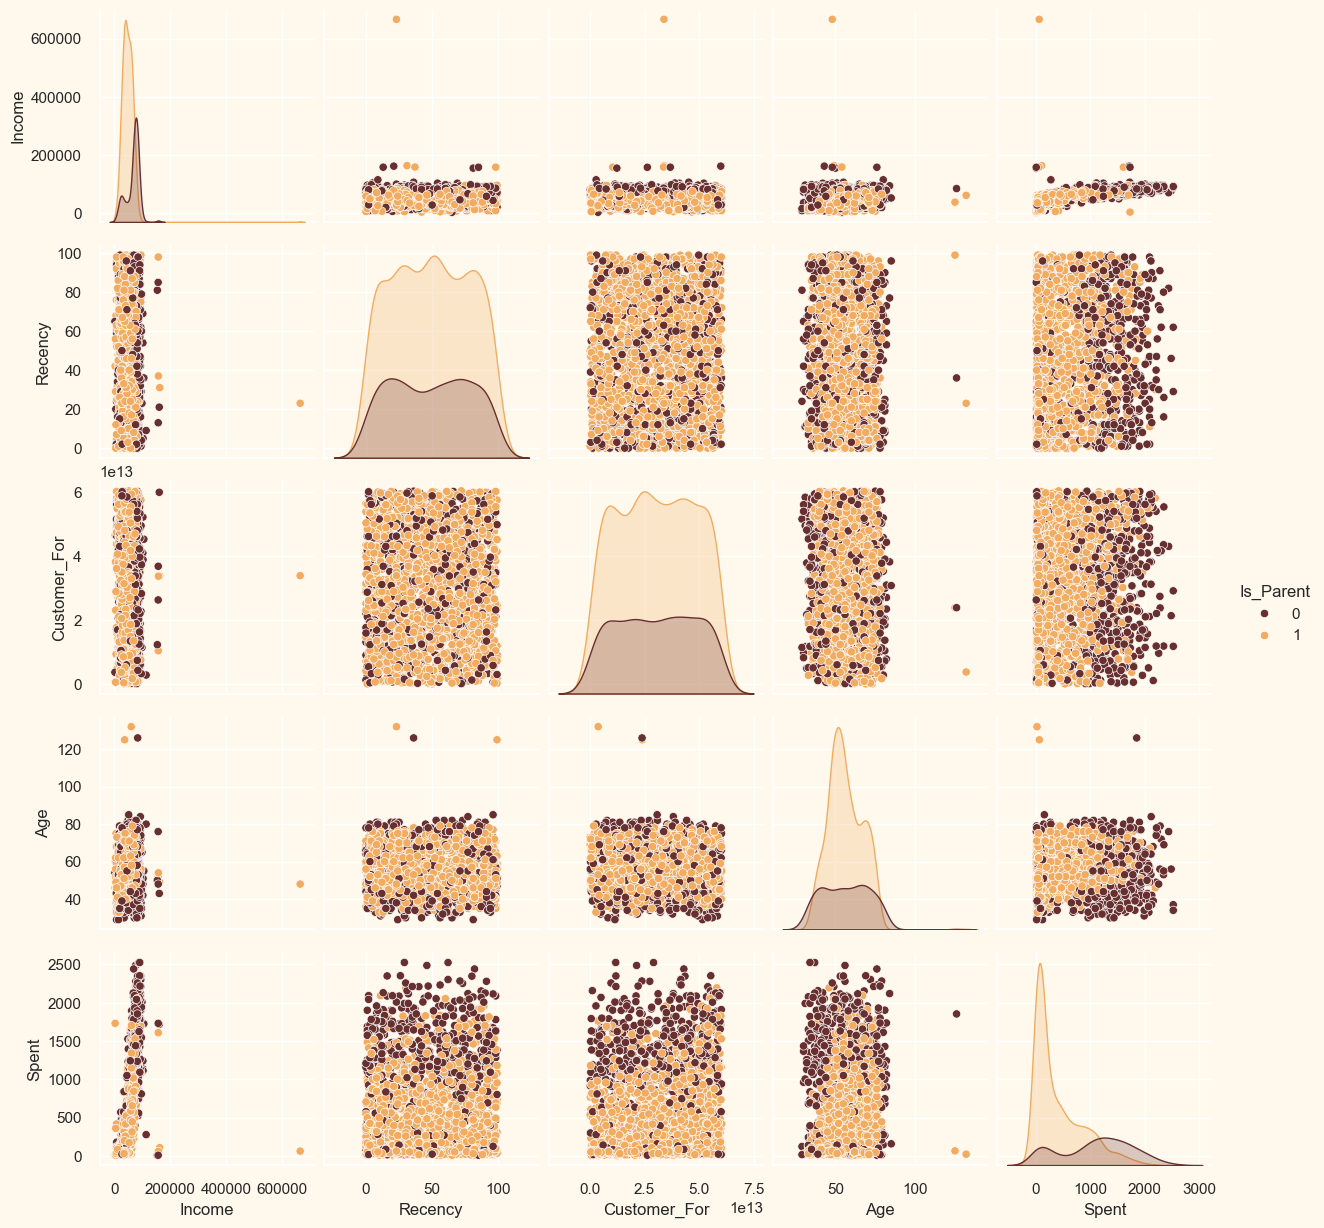

In [10]:
# STEP 08: PLOT THE SELECTED FEATURES

# Setting up colors preferences
sns.set(rc={"axes.facecolor":"#FFF9ED","figure.facecolor":"#FFF9ED"})
pallet = ["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"]
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])

# Plotting following features
To_Plot = [ "Income", "Recency", "Customer_For", "Age", "Spent", "Is_Parent"]
print("Relative Plot Of Some Selected Features: A Data Subset")
plt.figure()
sns.pairplot(data[To_Plot], hue= "Is_Parent",palette= (["#682F2F","#F3AB60"]))

# Taking hue
plt.show()

In [11]:
# STEP 09: DROPPING THE OUTLIER BY SETTING A CAP ON AGE AND INCOME

# Make an assumption here and taking notes of it
data = data[(data["Age"]<90)]
data = data[(data["Income"]<600000)]
print("The total number of data-points after removing the outliers are:", len(data))

The total number of data-points after removing the outliers are: 2212


In [12]:
data.info()

# Just to confirm that we have all rows with the non-null
# and the correct data type and finalize it

# The cleaning raw data process is done.

<class 'pandas.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   str    
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64  
 16  Acce

In [13]:
# Actual Machine Learning stage now!

# STEP 10: PRE-PROCESSING DATA BEFORE WE FEED INTO ML

# Get list of categorical variables
# Transforming our categorical values into numerical values
s = (data.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

Categorical variables in the dataset: ['Family_Size']


In [14]:
# Check Each columns for data types
print(data[["Education", "Living_With", "Family_Size"]].dtypes)

# Check if the Family_size has any weird values
print(data["Family_Size"].unique()[:10])

Education         str
Living_With       str
Family_Size    object
dtype: object
[1 3 2 4 5]


In [15]:
# STEP 11: LABEL ENCODING THE OBJECT DTYPES.

# Replace each columns or any unique with the integer 

# **** Very Manually ****

data['Education'] = data['Education'].astype(str)
data['Living_With'] = data['Living_With'].astype(str)

LE = LabelEncoder()
data['Education'] = LE.fit_transform(data['Education'])
data['Living_With'] = LE.fit_transform(data['Living_With'])

data['Education'] = data['Education'].astype(int)
data['Living_With'] = data['Living_With'].astype(int)

data['Family_Size'] = pd.to_numeric(data['Family_Size'], errors='coerce')
data['Family_Size'] = data['Family_Size'].fillna(0).astype(int)

print(data[['Education', 'Living_With', 'Family_Size']].dtypes)

print("All features are now numerical")

Education      int64
Living_With    int64
Family_Size    int64
dtype: object
All features are now numerical


In [16]:
data.info()

<class 'pandas.DataFrame'>
Index: 2212 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Education            2212 non-null   int64  
 1   Income               2212 non-null   float64
 2   Kidhome              2212 non-null   int64  
 3   Teenhome             2212 non-null   int64  
 4   Recency              2212 non-null   int64  
 5   Wines                2212 non-null   int64  
 6   Fruits               2212 non-null   int64  
 7   Meat                 2212 non-null   int64  
 8   Fish                 2212 non-null   int64  
 9   Sweets               2212 non-null   int64  
 10  Gold                 2212 non-null   int64  
 11  NumDealsPurchases    2212 non-null   int64  
 12  NumWebPurchases      2212 non-null   int64  
 13  NumCatalogPurchases  2212 non-null   int64  
 14  NumStorePurchases    2212 non-null   int64  
 15  NumWebVisitsMonth    2212 non-null   int64  
 16  Acce

In [17]:
# STEP 12: CREATING A COPY OF DATA

ds = data.copy()

# Creating a subset of dataframe by dropping the features on deals accepted and promotions
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1','AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1)

# Scaling
# When we convert into a number we are going to work with it

scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds),columns= ds.columns )

print("All features are now scaled")

All features are now scaled


In [18]:
 # STEP 13: SCALED DATA TO BE USED FOR REDUCING THE DIMENSIONALITY

print("Dataframe to be used for further modelling:")
scaled_ds.head()

# All of the numbers that we have are included between -1 and 1
# Dimensionality reductions = reducing the number of random variables under consideration by obtaining a set of principal variables.
# We also use PCA as well (reducing the dimensionality of our datasets)

Dataframe to be used for further modelling:


,Education,Income,Kidhome,Teenhome,Recency,Wines,Fruits,Meat,Fish,Sweets,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Customer_For,Age,Spent,Living_With,Children,Family_Size,Is_Parent
0,-0.893586,0.287105,-0.822754,-0.929699,0.310353,0.977660,1.552041,1.690293,2.453472,1.483713,...,2.503607,-0.555814,0.692181,1.527721,1.018352,1.676245,-1.349603,-1.264598,-1.758359,-1.581139
1,-0.893586,-0.260882,1.040021,0.908097,-0.380813,-0.872618,-0.637461,-0.718230,-0.651004,-0.634019,...,-0.571340,-1.171160,-0.132545,-1.189011,1.274785,-0.963297,-1.349603,1.404572,0.449070,0.632456
2,-0.893586,0.913196,-0.822754,-0.929699,-0.795514,0.357935,0.570540,-0.178542,1.339513,-0.147184,...,-0.229679,1.290224,-0.544908,-0.206048,0.334530,0.280110,0.740959,-1.264598,-0.654644,-1.581139
3,-0.893586,-1.176114,1.040021,-0.929699,-0.795514,-0.872618,-0.561961,-0.655787,-0.504911,-0.585335,...,-0.913000,-0.555814,0.279818,-1.060584,-1.289547,-0.920135,0.740959,0.069987,0.449070,0.632456
4,0.571657,0.294307,1.040021,-0.929699,1.554453,-0.392257,0.419540,-0.218684,0.152508,-0.001133,...,0.111982,0.059532,-0.132545,-0.951915,-1.033114,-0.307562,0.740959,0.069987,0.449070,0.632456


In [19]:
# INITIATING PCA TO REDUCE DIMENSIONALITY AKA. FEATURES TO 3

pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.fit_transform(scaled_ds), columns=(["col1", "col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,2212.0,0.000000e+00,2.878602,-5.978124,-2.539470,-0.781595,2.386380,7.452915
col2,2212.0,3.212219e-17,1.709469,-4.194757,-1.323929,-0.173721,1.234851,6.168189
col3,2212.0,-4.818328e-18,1.231687,-3.625248,-0.853713,-0.050842,0.863974,6.750458


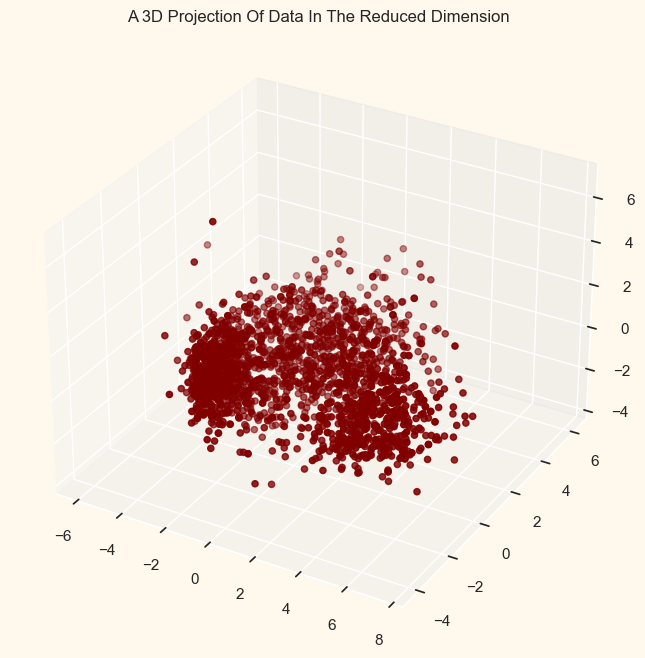

In [20]:
# A 3D Projection Of Data In The Reduced Dimension
x =PCA_ds["col1"]
y =PCA_ds["col2"]
z =PCA_ds["col3"]

# Try to plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z, c="maroon", marker="o" )
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

# Put the data into 3D dimensions to see all of the customers
# So we can make a clusters based on this informations

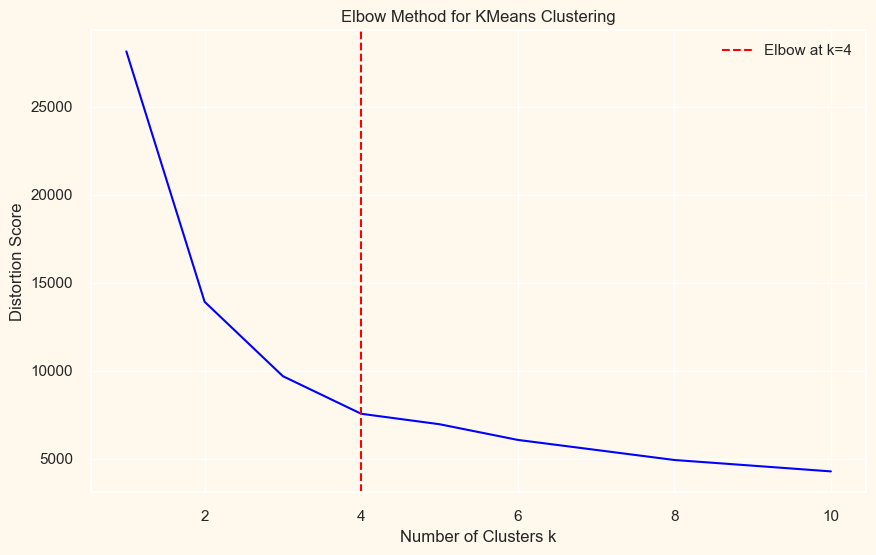

In [21]:
# STEP 13: QUICK EXAMINATION OF ELBOW METHOD TO FIND NUMBERS OF CLUSTERS TO MAKE
# You need to understand first how many clusters you really need to create based on customers on the data 

# **** Very Manually ****

distortions = []
K = range(1, 11)

for k in K:
    km = KMeans(n_clusters=k, n_init='auto', random_state=42)
    km.fit(PCA_ds)
    distortions.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, distortions, 'bx-', color='blue')
plt.xlabel('Number of Clusters k')
plt.ylabel('Distortion Score')
plt.title('Elbow Method for KMeans Clustering')
plt.axvline(x=4, color='red', linestyle='--', label='Elbow at k=4')
plt.legend()
plt.show()

# What the elbow methods doing is highlight the elbow concepts
# I need to choose the point where this line is not that steep anymore
# Try to optimal amount of clusters that we have to make from the datasets

In [22]:
# Initiating the Agglomerative Clustering model
# Every data points is a cluster on its own and the algorithm meaures how close clusters are to each other
AC = AgglomerativeClustering(n_clusters=4)

# fit model and predict clusters
yhat_AC = AC.fit_predict(PCA_ds)
PCA_ds["Clusters"] = yhat_AC

# Adding the Clusters feature to the orignal dataframe.
data["Clusters"]= yhat_AC

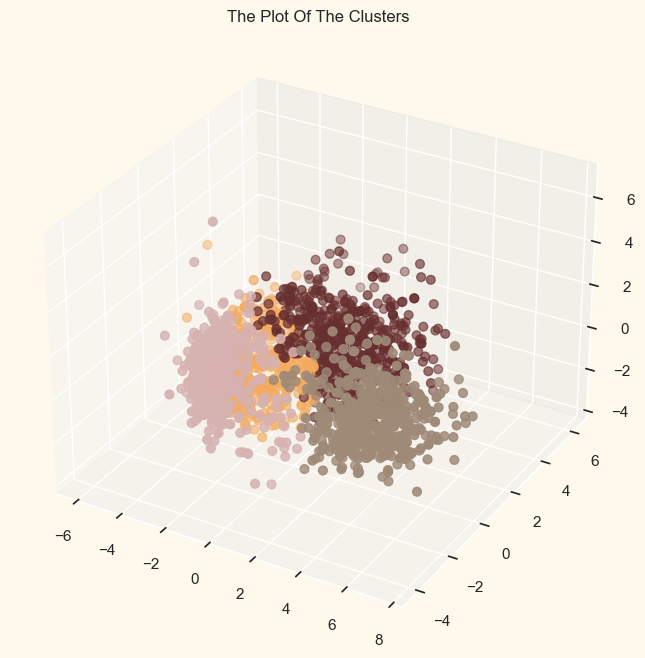

In [23]:
# STEP 14: PLOTTING THE CLUSTERS

fig = plt.figure(figsize=(10,8))
ax = plt.subplot(111, projection='3d', label="bla")
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"], marker='o', cmap = cmap )
ax.set_title("The Plot Of The Clusters")
plt.show()

# We do not have a scofre for our model to see the accuracy of our model (Unsup. Learning)

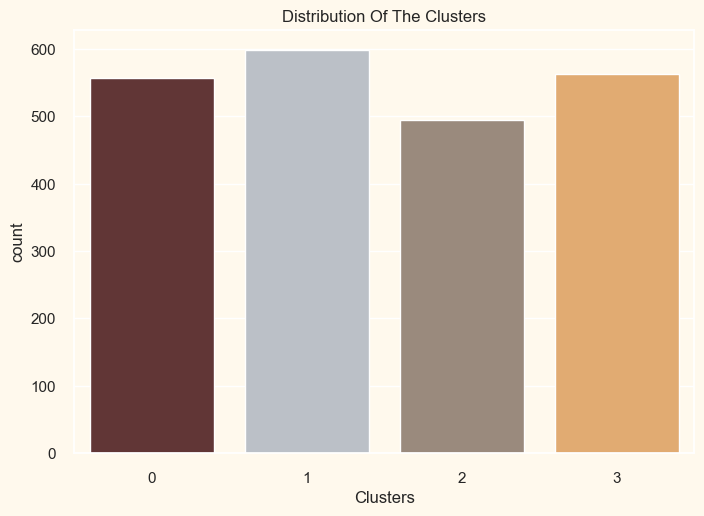

In [24]:
# Plotting countplot of clusters

pal = ["#682F2F","#B9C0C9", "#9F8A78","#F3AB60"]
pl = sns.countplot(x=data["Clusters"], palette= pal)
pl.set_title("Distribution Of The Clusters")
plt.show()

# We wanna make sure pretty much we have a similar distributions of customers in the clusters

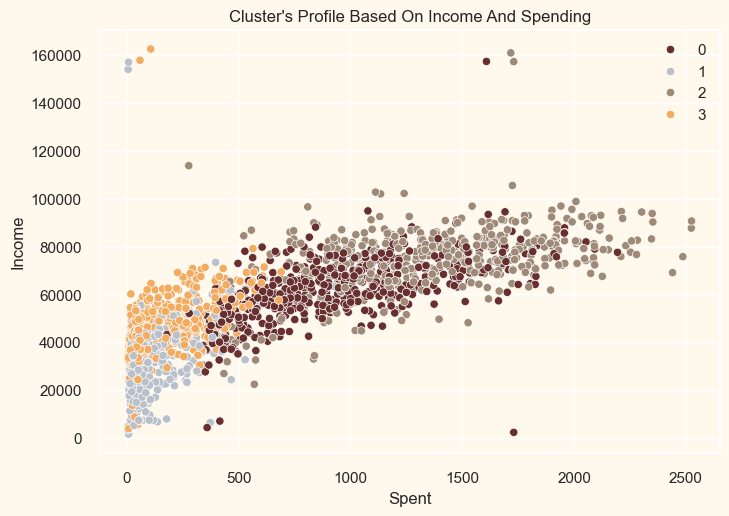

In [25]:
# Try plotting the different features
pl = sns.scatterplot(data = data,x=data["Spent"], y=data["Income"],hue=data["Clusters"], palette= pal)
pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend()
plt.show()

# Just to see how clusters are changing 

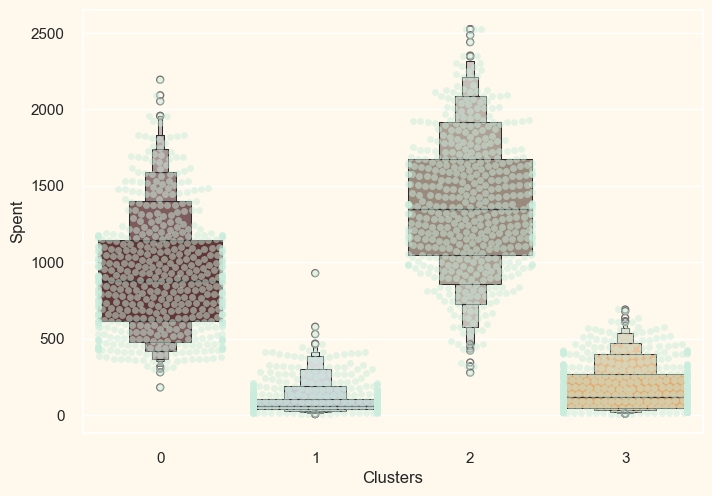

In [26]:
# Analyzing the spend data only
plt.figure()
pl=sns.swarmplot(x=data["Clusters"], y=data["Spent"], color= "#CBEDDD", alpha=0.5 )
pl=sns.boxenplot(x=data["Clusters"], y=data["Spent"], palette=pal)
plt.show()

# From this plot I can see that our main customer would be cluster number 2 followed by number 0
# clusters 1 and 3 are a bit less important in terms of aount that they spend

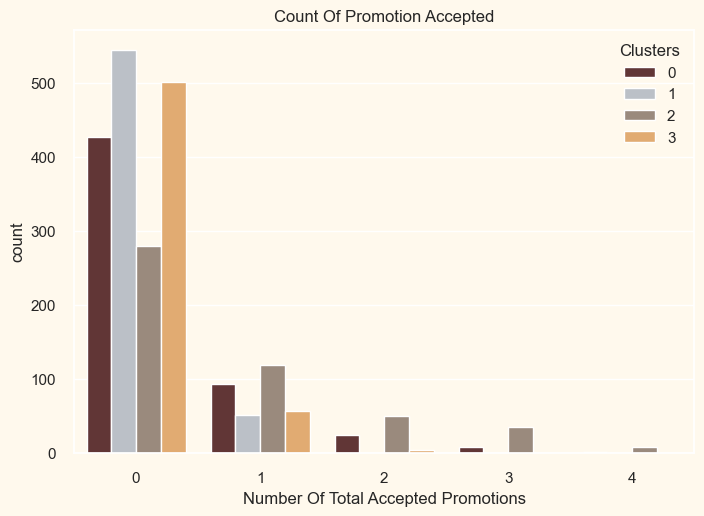

In [27]:
# STEP 15: CREATING A FEATURES TO GET A SUM OF ACCEPTED PROMOTIONS

# Sum the campaigns accepted that we have in the plotting 
data["Total_Promos"] = data["AcceptedCmp1"]+ data["AcceptedCmp2"]+ data["AcceptedCmp3"]+ data["AcceptedCmp4"]+ data["AcceptedCmp5"]

# Plotting count of total campaign accepted.
plt.figure()
pl = sns.countplot(x=data["Total_Promos"],hue=data["Clusters"], palette= pal)
pl.set_title("Count Of Promotion Accepted")
pl.set_xlabel("Number Of Total Accepted Promotions")
plt.show()

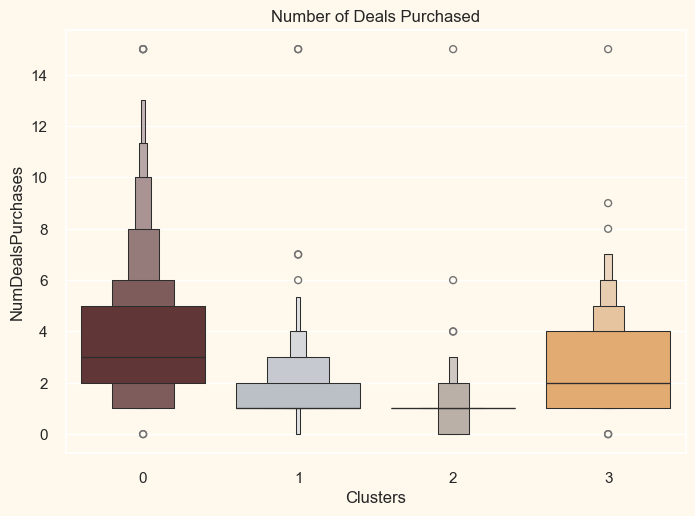

In [28]:
# Summarize all the plotting the number of deals purchased

plt.figure()
pl=sns.boxenplot(y=data["NumDealsPurchases"],x=data["Clusters"], palette= pal)
pl.set_title("Number of Deals Purchased")
plt.show()

# Cluster 0 is definitely the one with the higher number of deals purchased

<Figure size 800x550 with 0 Axes>

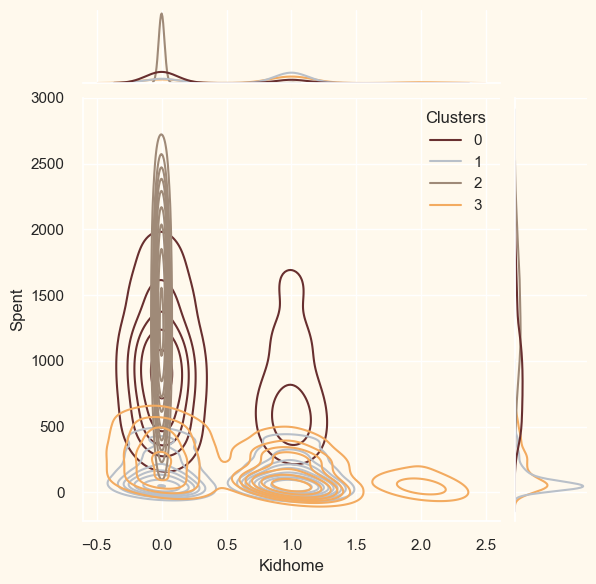

<Figure size 800x550 with 0 Axes>

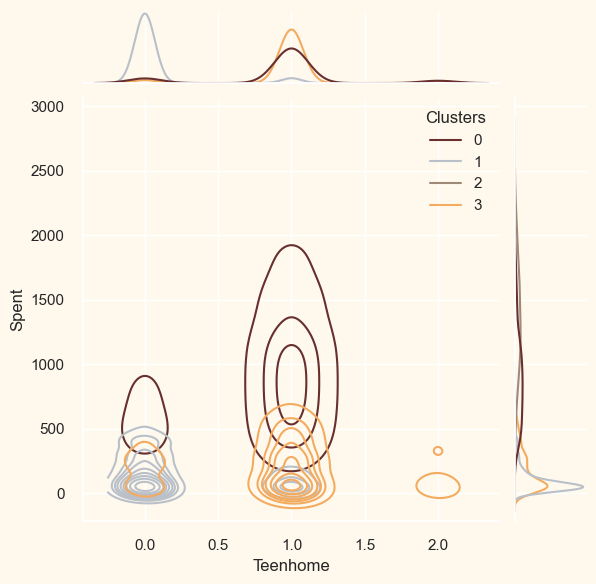

<Figure size 800x550 with 0 Axes>

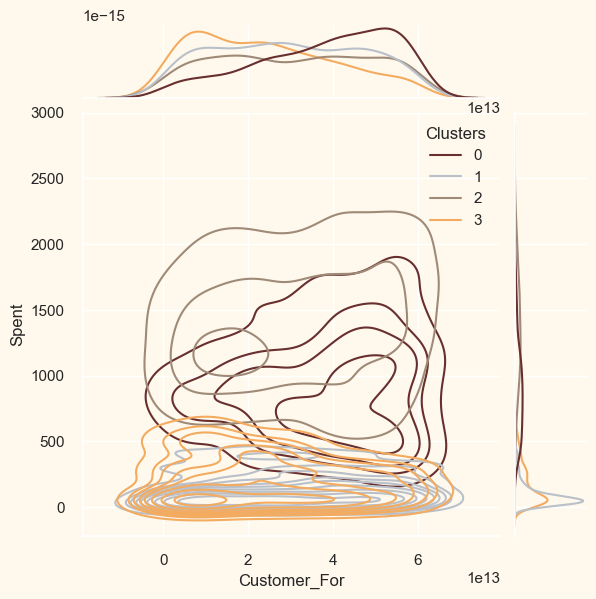

<Figure size 800x550 with 0 Axes>

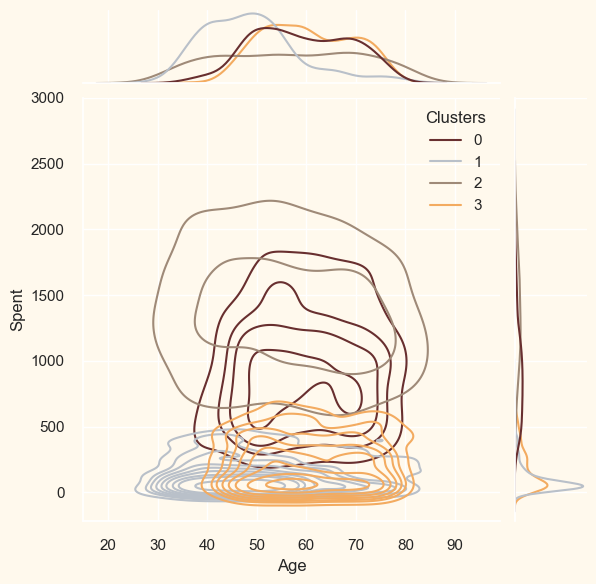

<Figure size 800x550 with 0 Axes>

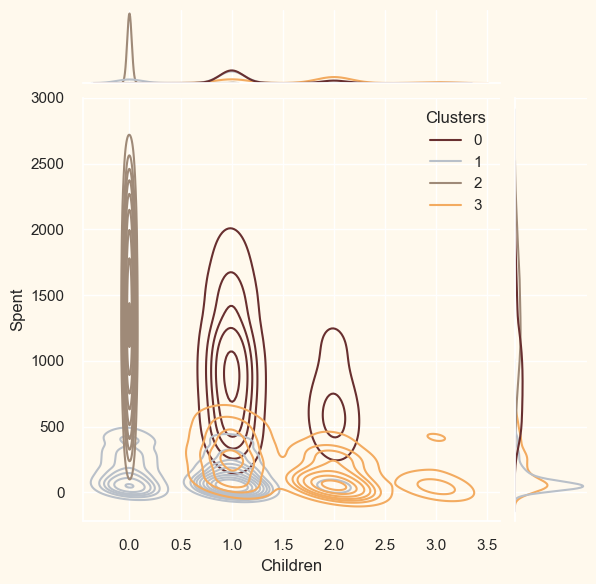

<Figure size 800x550 with 0 Axes>

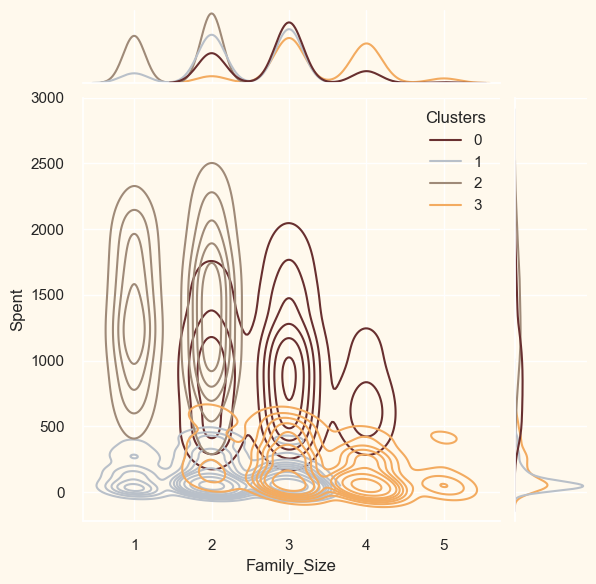

<Figure size 800x550 with 0 Axes>

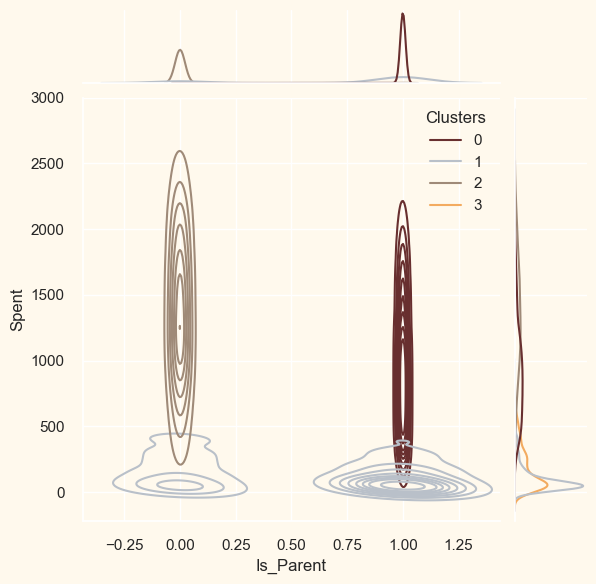

<Figure size 800x550 with 0 Axes>

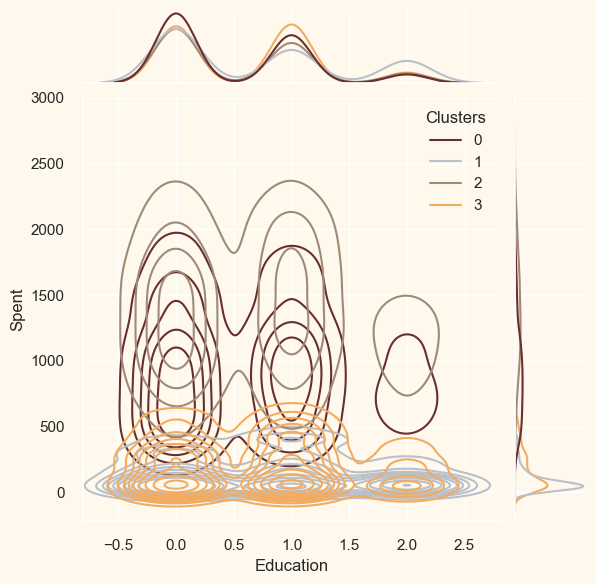

<Figure size 800x550 with 0 Axes>

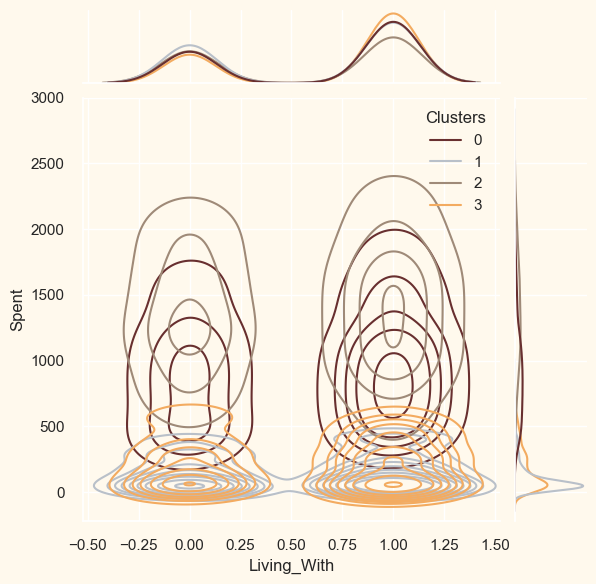

In [29]:
# Try to plot all the kind of personal information about the customer that we got here.

Personal = [ "Kidhome","Teenhome","Customer_For", "Age", "Children", "Family_Size", "Is_Parent", "Education","Living_With"]

for i in Personal:
    plt.figure()
    sns.jointplot(x=data[i], y=data["Spent"], hue =data["Clusters"], kind="kde", palette=pal)
    plt.show()

    # Grapgh 1, the cluster 3 is the one where in the majority of the cases
    # 